In [47]:
import jax
import jax.numpy as jnp
import time
import optax
import matplotlib.pyplot as plt
import ot
import torchdyn
from ott.neural.networks import icnn
from ott.neural.methods import neuraldual
from sklearn.datasets import make_blobs, make_swiss_roll, make_moons
import flax.linen as nn
import numpy as np
from collections import namedtuple
import itertools
from scipy.spatial.distance import cdist
from ott.tools.sinkhorn_divergence import sinkhorn_divergence
from ott.geometry.pointcloud import PointCloud

Defining Chamfer distance :

In [48]:
def chamfer_distance(point_cloud1, point_cloud2):
    pairwise_distances = cdist(point_cloud1, point_cloud2, metric='euclidean')
    
    total_distance = 0.0
    for i in range(len(point_cloud1)):
        total_distance += np.min(pairwise_distances[i])
        
    return total_distance / len(point_cloud1)

## 1) Generating synthetic data

In [66]:
X_np, _ = make_blobs(n_samples=1000, n_features=2, centers=[[0, 0]], random_state=42)
Y_np, _ = make_blobs(n_samples=1000, n_features=2, centers=[[0, 10], [0, -10]], random_state=43)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)


n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

def infinite_iterator(data):
    while True:
        yield data

DataLoader = namedtuple("DataLoader", ["source_iter", "target_iter"])
train_dtld = DataLoader(source_iter=infinite_iterator(X_train),
                               target_iter=infinite_iterator(Y_train))
valid_dtld = DataLoader(source_iter=infinite_iterator(X_valid),
                               target_iter=infinite_iterator(Y_valid))

X = next(train_dtld.source_iter)
Y = next(train_dtld.target_iter)
X_valid = next(valid_dtld.source_iter)
Y_valid = next(valid_dtld.target_iter)

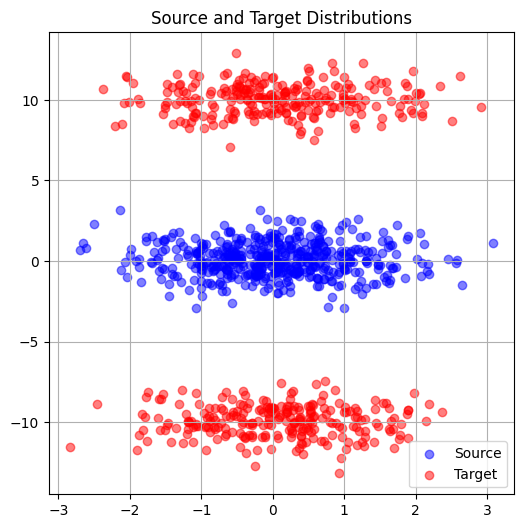

In [50]:
X_np = jnp.array(X).to_py() if hasattr(X, 'to_py') else jnp.array(X)
Y_np = jnp.array(Y).to_py() if hasattr(Y, 'to_py') else jnp.array(Y)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], color='blue', alpha=0.5, label='Source')
plt.scatter(Y_np[:, 0], Y_np[:, 1], color='red', alpha=0.5, label='Target')
plt.title("Source and Target Distributions")
plt.legend()
plt.grid(True)
plt.show()

## 2) Testing the ICNN on the Gaussian blob data

  0%|          | 0/2000 [00:00<?, ?it/s]

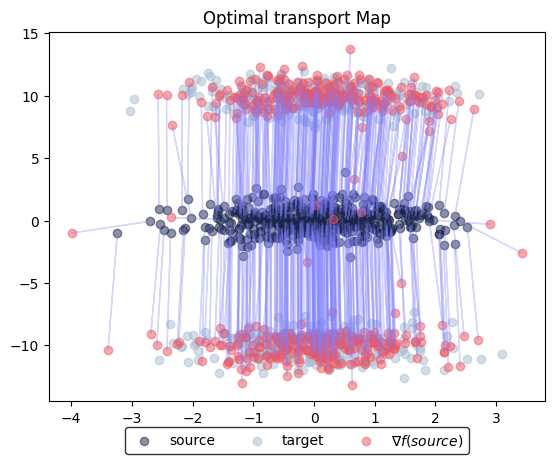

Approximate Wasserstein distance: 0.90999997
Chamfer distance: 0.23
Neural dual distance: 83.92
CPU times: user 40min 49s, sys: 1min 40s, total: 42min 30s
Wall time: 21min 18s


In [55]:
%%time
nn_f = icnn.ICNN(dim_hidden=[64, 64, 32, 32], dim_data=2)
nn_g = icnn.ICNN(dim_hidden=[64, 64, 32, 32], dim_data=2)

opti_f = optax.adam(learning_rate=1e-3)
opti_g = optax.adam(learning_rate=1e-3)

nn_dual_solver = neuraldual.W2NeuralDual(2, nn_f, nn_g, opti_f, opti_g, num_train_iters = 2000)
learned_map = nn_dual_solver(*train_dtld, *valid_dtld)

learned_map.plot_ot_map(X_valid, Y_valid, forward=True)
plt.title("Optimal transport Map")
plt.show()

transported_X = learned_map.transport(X_valid, forward = True)

wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y_valid, epsilon=0.1, 
                                a=jnp.ones(len(transported_X)) / len(transported_X), b=jnp.ones(len(Y_valid)) / len(Y_valid))[0]
print("Approximate Wasserstein distance:", np.round(wass_dist, 2))

cf_dist = chamfer_distance(transported_f, Y_valid)
print("Chamfer distance:", np.round(cf_dist,2))

dual_dist = learned_map.distance(X_valid, Y_valid)
print("Neural dual distance:", np.round(dual_dist,2))

## 2) Testing the ICNN on the moon data

In [79]:
X_np, labels_X = make_moons(n_samples=1000, noise=0.1, random_state=42)
Y_np, labels_Y = make_moons(n_samples=1000, noise=0.1, random_state=42)
offset = np.array([3, 3])
Y_np = Y_np + offset

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)

n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

def infinite_iterator(data):
    while True:
        yield data

DataLoader = namedtuple("DataLoader", ["source_iter", "target_iter"])
train_dtld = DataLoader(source_iter=infinite_iterator(X_train),
                               target_iter=infinite_iterator(Y_train))
valid_dtld = DataLoader(source_iter=infinite_iterator(X_valid),
                               target_iter=infinite_iterator(Y_valid))

X = next(train_dtld.source_iter)
Y = next(train_dtld.target_iter)
X_valid = next(valid_dtld.source_iter)
Y_valid = next(valid_dtld.target_iter)

  0%|          | 0/2000 [00:00<?, ?it/s]

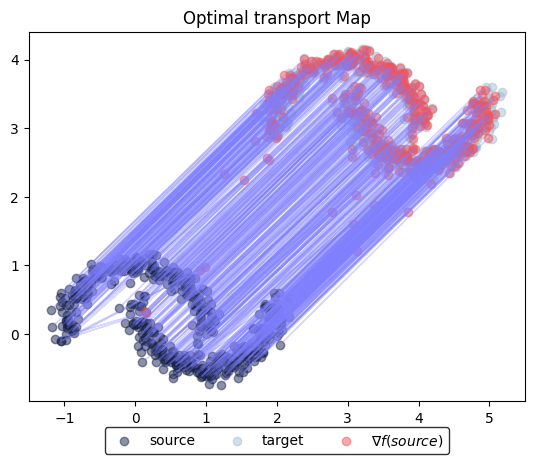

Approximate Wasserstein distance: 0.08
Chamfer distance: 9.56
Neural dual distance: 17.99
CPU times: user 39min 42s, sys: 1min 35s, total: 41min 18s
Wall time: 20min 36s


In [81]:
%%time
nn_f = icnn.ICNN(dim_hidden=[64, 64, 32, 32], dim_data=2)
nn_g = icnn.ICNN(dim_hidden=[64, 64, 32, 32], dim_data=2)

opti_f = optax.adam(learning_rate=1e-3)
opti_g = optax.adam(learning_rate=1e-3)

nn_dual_solver = neuraldual.W2NeuralDual(2, nn_f, nn_g, opti_f, opti_g, num_train_iters = 2000)
learned_map = nn_dual_solver(*train_dtld, *valid_dtld)

learned_map.plot_ot_map(X_valid, Y_valid, forward=True)
plt.title("Optimal transport Map")
plt.show()

transported_X = learned_map.transport(X_valid, forward = True)

wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y_valid, epsilon=0.1, 
                                a=jnp.ones(len(transported_X)) / len(transported_X), b=jnp.ones(len(Y_valid)) / len(Y_valid))[0]
print("Approximate Wasserstein distance:", np.round(wass_dist, 2))

cf_dist = chamfer_distance(transported_f, Y_valid)
print("Chamfer distance:", np.round(cf_dist,2))

dual_dist = learned_map.distance(X_valid, Y_valid)
print("Neural dual distance:", np.round(dual_dist,2))

## 3) Testing the ICNN on the Swiss roll data

In [21]:
X_np, _ = make_swiss_roll(n_samples=1000, noise=1.5, random_state=42)
Y_np, _ = make_swiss_roll(n_samples=1000, noise=0, random_state=42)

X_all = jnp.array(X_np)
Y_all = jnp.array(Y_np)


n_samples = 500 
X_train, X_valid = X_all[:n_samples], X_all[n_samples:2*n_samples]
Y_train, Y_valid = Y_all[:n_samples], Y_all[n_samples:2*n_samples]

def infinite_iterator(data):
    while True:
        yield data

DataLoader = namedtuple("DataLoader", ["source_iter", "target_iter"])
train_dtld = DataLoader(source_iter=infinite_iterator(X_train),
                               target_iter=infinite_iterator(Y_train))
valid_dtld = DataLoader(source_iter=infinite_iterator(X_valid),
                               target_iter=infinite_iterator(Y_valid))

X = next(train_dtld.source_iter)
Y = next(train_dtld.target_iter)
X_valid = next(valid_dtld.source_iter)
Y_valid = next(valid_dtld.target_iter)

In [23]:
%%time
opti_f = optax.adam(learning_rate=1e-3)
opti_g = optax.adam(learning_rate=1e-3)

nn_f = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)
nn_g = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)

nn_dual_solver = neuraldual.W2NeuralDual(3, nn_f, nn_g, opti_f, opti_g, num_train_iters = 2000)
learned_map = nn_dual_solver(*train_dtld, *valid_dtld)

transported_f = learned_map.transport(X_valid, forward = True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_valid[:, 0], X_valid[:, 1], X_valid[:, 2], c='green', label='Source', alpha=0.6)
ax.scatter(Y_valid[:, 0], Y_valid[:, 1], Y_valid[:, 2], c='red', label='Target', alpha=0.6)
ax.scatter(transported_f[:, 0], transported_f[:, 1], transported_f[:, 2], c='blue', label='Transported source', alpha=0.5)

ax.set_title('Swiss Rolls with transported data')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()

ax.view_init(elev=5, azim=90)

plt.tight_layout()
plt.show()

wass_dist = sinkhorn_divergence(PointCloud, transported_X, Y_valid, epsilon=0.1, 
                                a=jnp.ones(len(transported_X)) / len(transported_X), b=jnp.ones(len(Y_valid)) / len(Y_valid))[0]
print("Approximate Wasserstein distance:", np.round(wass_dist, 2))

cf_dist = Chamfer_distance(transported_f, Y_valid)
print("Chamfer distance:", np.round(cf_dist,2))

dual_dist = learned_map.distance(X_valid, Y_valid)
print("Neural dual distance:", np.round(dual_dist,2))

  0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 